# SIT720 – Task 8.1D: Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System

**Name:** Jason Hu  **Student ID:** 219220123

**Dataset:** hand-collected sold-property records from three Sydney suburbs — **Bondi**, **Chatswood**
and **Penrith** — gathered from Domain listings and stored in `data/sydney_properties.csv`. Each row is
one sold property with its sale price, physical characteristics, sale details and the agent's
description.

These three suburbs were chosen because each represents a different reason to buy. **Bondi** is a
scarcity play: beachside land is genuinely fixed in supply, so the premium tends to hold through
downturns and you are buying the postcode's floor price more than the dwelling. **Chatswood** is an
access play: the Metro, the North Shore line, the school catchments and a real town centre deliver
CBD-grade access at apartment-grade entry prices. **Penrith** is an infrastructure play: the Western
Sydney Airport and Aerotropolis spend is the only genuine re-rating story of the three, and at
sub-$1M with 550-650 sqm of land the land component is cheap enough that the house barely matters.

A model that has to price all three must learn that the same physical dwelling is worth very
different amounts depending on where it stands. It also puts each of those three theses in front of
evidence, and Part 6 returns to how well they survived it.

The project runs the full lifecycle: defining the problem and collecting the data, understanding and
engineering features, training and comparing three regression models with cross-validation,
investigating the model's worst predictions, comparing the model against a large language model and
against my own judgement, and finally deploying the model as a web application.

In [1]:
import json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_predict,
                                     cross_validate, GridSearchCV, learning_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
SUBURBS = ["Bondi", "Chatswood", "Penrith"]

## Part 1. Problem definition and data collection

**The problem.** Given a property's suburb, physical characteristics and the agent's description,
predict its **sale price** in Australian dollars. This is a supervised regression problem. The practical
motivation is a decision support tool for a real estate agency: a buyer or agent enters a property's
details and receives an indicative valuation, together with an honest sense of how reliable that
number is.

**How the data was collected.** Domain's *Sold* listings were used, filtered to the last twelve months
so that all sales sit in a comparable market. For each property I recorded the sale price, suburb,
address, property type, bedrooms, bathrooms, car spaces, land and internal area where stated, the sale
date and method, days on market, walking distance to the nearest railway station, and the opening
sentences of the agent's description. Properties advertised without a disclosed price were skipped,
because the target variable would be missing.

The cell below loads the file and checks it against what the brief requires.

In [2]:
DATA = Path("data/sydney_properties.csv")
props = pd.read_csv(DATA)

props = props[~props["address"].astype(str).str.startswith("EXAMPLE")].reset_index(drop=True)

print(f"Properties collected: {len(props)}")
print(f"Columns: {props.shape[1]}")
print("\nPer suburb:")
print(props["suburb"].value_counts().reindex(SUBURBS).to_string())

ok_total = len(props) >= 100
ok_each = props["suburb"].value_counts().reindex(SUBURBS).min() >= 30
print(f"\nAt least 100 properties overall: {ok_total}")
print(f"At least 30 in every suburb:     {ok_each}")

props["sale_date"] = pd.to_datetime(props["sale_date"])
print(f"\nSales span {props['sale_date'].min():%d %b %Y} to {props['sale_date'].max():%d %b %Y}")

print("\nMissing values per column:")
miss = props.isna().sum()
print(miss[miss > 0].to_string() if miss.sum() else "  none")

print("\nSale price summary:")
print(props["sale_price"].describe().apply(lambda v: f"{v:,.0f}").to_string())

Properties collected: 201
Columns: 17

Per suburb:
suburb
Bondi        75
Chatswood    51
Penrith      75

At least 100 properties overall: True
At least 30 in every suburb:     True

Sales span 10 Feb 2026 to 23 Sep 2026

Missing values per column:
land_size_sqm             122
internal_area_sqm         201
days_on_market            201
distance_to_station_km    201
agent_description         201
listing_url               201
agent_agency               54

Sale price summary:
count          201
mean     1,611,045
std      1,301,218
min        325,000
25%        675,000
50%      1,200,000
75%      2,110,000
max      8,725,000


In [3]:
print("Data types and how complete each column is:\n")
summary = pd.DataFrame({
    "dtype": props.dtypes.astype(str),
    "non_null": props.notna().sum(),
    "missing_%": (props.isna().mean() * 100).round(1),
    "unique": props.nunique()})
print(summary.to_string())

print("\nProperty types collected in each suburb:")
print(pd.crosstab(props["suburb"], props["property_type"]).to_string())

print("\nSale price by suburb:")
print(props.groupby("suburb")["sale_price"].agg(
    n="count", median="median", mean="mean", min="min", max="max").round(0).to_string())

Data types and how complete each column is:

                                 dtype  non_null  missing_%  unique
property_id                      int64       201        0.0     201
suburb                             str       201        0.0       3
address                            str       201        0.0     201
property_type                      str       201        0.0       5
bedrooms                         int64       201        0.0       7
bathrooms                        int64       201        0.0       5
car_spaces                       int64       201        0.0       5
land_size_sqm                  float64        79       60.7      74
internal_area_sqm              float64         0      100.0       0
sale_price                       int64       201        0.0     168
sale_date               datetime64[us]       201        0.0     117
sale_method                        str       201        0.0       2
days_on_market                 float64         0      100.0       0
dis

In [4]:
print("Cleaning the area field")
print()

is_unit = props["property_type"] == "Apartment"
stated = props["land_size_sqm"].notna()

AREA_CUTOFF = 300
internal = is_unit & stated & (props["land_size_sqm"] <= AREA_CUTOFF)
site = is_unit & stated & (props["land_size_sqm"] > AREA_CUTOFF)

kept_lo, kept_hi = props.loc[internal, "land_size_sqm"].agg(["min", "max"])
cut_lo, cut_hi = props.loc[site, "land_size_sqm"].agg(["min", "max"])

props.loc[internal, "internal_area_sqm"] = props.loc[internal, "land_size_sqm"]
props.loc[is_unit, "land_size_sqm"] = np.nan

print(f"Apartments quoting an area: {int((is_unit & stated).sum())}")
print(f"  <= {AREA_CUTOFF} sqm, read as the dwelling's internal area: {int(internal.sum())}")
print(f"     these run {kept_lo:.0f} to {kept_hi:.0f} sqm")
print(f"  >  {AREA_CUTOFF} sqm, discarded as the strata block's site area: {int(site.sum())}")
print(f"     these run {cut_lo:.0f} to {cut_hi:.0f} sqm, so nothing sits between "
      f"{kept_hi:.0f} and {cut_lo:.0f}")
print(f"Land size retained for {int(props['land_size_sqm'].notna().sum())} houses and "
      f"attached dwellings")

print()
print("Land size by property type after cleaning:")
print(props[props["land_size_sqm"].notna()].groupby("property_type")["land_size_sqm"]
      .agg(n="size", min="min", median="median", max="max").round(0).to_string())

empty = [c for c in props.columns if props[c].isna().all()]
props = props.drop(columns=empty)
print()
print(f"Columns dropped because nothing was collected into them: {empty}")

Cleaning the area field

Apartments quoting an area: 43
  <= 300 sqm, read as the dwelling's internal area: 27
     these run 47 to 229 sqm
  >  300 sqm, discarded as the strata block's site area: 16
     these run 627 to 28725 sqm, so nothing sits between 229 and 627
Land size retained for 36 houses and attached dwellings

Land size by property type after cleaning:
                n    min  median     max
property_type                           
Duplex          1  614.0   614.0   614.0
House          33  212.0   518.0  1067.0
Semi            1  359.0   359.0   359.0
Townhouse       1  624.0   624.0   624.0

Columns dropped because nothing was collected into them: ['days_on_market', 'distance_to_station_km', 'agent_description', 'listing_url']


**Dataset quality, challenges, bias and limitations.**
**Why these three suburbs.** Each was picked for a different reason to buy, and each reason is a
claim this project can test.

- **Bondi — scarcity.** Beachside land is fixed in supply, so the premium tends to hold through
  downturns. The implication is that you are buying the postcode's floor price more than the dwelling
  itself.
- **Chatswood — access and liquidity.** The Metro and the North Shore line, the school catchments and
  a genuine town centre give CBD-grade access at apartment-grade entry prices, which makes it the best
  liquidity-to-cost trade of the three.
- **Penrith — infrastructure.** The Western Sydney Airport and Aerotropolis programme is the only
  real infrastructure-led re-rating story on the list. At under $1M for 550-650 sqm, the land is cheap
  enough that the dwelling on it barely matters.

These are also the reason the three make a sensible modelling problem: they are priced by different
mechanisms, so a model forced to handle all three cannot get away with a single rule.

**What was collected.** 201 sold properties — **75 Bondi, 51 Chatswood, 75 Penrith** — from sales
settled between **10 February and 23 September 2026**. That clears the brief's minimum of 100 overall
and 30 per suburb. Every property carries suburb, address, type, bedrooms, bathrooms, car spaces, sale
price, sale date and sale method; land or internal area is present where the listing stated it.

**How it was collected, and why that shaped everything.** Domain publishes no data export, so each
results page was opened in a browser, selected and copied into a text file, and a parser
(`parse_domain.py`) turned those files into rows. Fourteen pages were copied in total. Doing it this
way is reproducible and auditable — the raw pages are kept alongside the code — but it also means the
dataset contains only what a results card shows.

**Challenges encountered.**

- **Withheld prices.** 73 of the 275 listings seen (27%) were advertised as "Price Withheld" and had
  to be discarded, because the target variable was missing.
- **An ambiguous area field.** Domain prints a single `m²` figure that means different things for
  different listings. For 27 apartments it was between 47 and 229 sqm — the dwelling's internal area.
  For 16 others it ran from 627 to **28,725 sqm** — the entire strata block's site area. One
  2-bedroom Penrith apartment sold for $325,000 was recorded against 2.9 hectares of "land". The
  values separate cleanly with nothing between 229 and 627 sqm, so apartment figures at or below 300
  sqm were reassigned to internal area and the rest discarded. Left uncorrected, this single field
  would have destroyed any relationship between land and price.
- **Inconsistent type labels.** Some properties with unit numbers are classed by Domain as houses.
  These were left as listed rather than reclassified by guesswork.
- **Suburb bleed.** Domain returns results for the suburb "and surroundings", so Bondi Beach and
  Bondi Junction appear in a Bondi search. Only exact suburb matches were kept.
- **Fields that do not exist on a results card.** Days on market, distance to a station, the listing
  URL and the agent's description are not shown, so those columns stayed empty and were dropped.

**Sources of bias — the most important limitation of this dataset.** Price withholding is **not random
and not evenly spread**:

| Suburb | Listings seen | Withheld | Rate |
|---|---|---|---|
| Penrith | 78 | 3 | **4%** |
| Bondi | 98 | 22 | **22%** |
| Chatswood | 99 | 48 | **49%** |

Almost half of Chatswood's sales could not be collected at all. Vendors and agents typically withhold
at the top of the market and on disappointing results, so the missing half is unlikely to resemble the
half that remains. Anything this project concludes about Chatswood rests on a sample drawn from a
non-random 52% of its market — and Part 3 shows that this is exactly where the model performs worst.

Three further biases follow from the collection method. The suburbs cover **unequal time windows**
(Bondi from February, Chatswood from May, Penrith from June), because the withholding rate determined
how far back five pages reached; any apparent time trend is therefore confounded with suburb. Only
**sold** properties appear, so withdrawn and passed-in properties are invisible. And the sample is
**apartment-heavy** — 142 of 201 are not houses — which reflects what actually trades in these
suburbs but leaves relatively few houses to learn from.

**Limitations affecting validity.** The dataset records *quantity* but almost nothing about *quality*.
There is no measure of condition, renovation state, aspect, outlook, noise, or strata levy, because
none is published on a results page. Two properties identical in every recorded field can differ in
price by a factor of two, and the model has no way to tell them apart. That sets a ceiling on
achievable accuracy which no choice of algorithm can lift, and Part 4 shows it is precisely where the
largest errors come from.

## Part 2. Data understanding and feature engineering

Before engineering anything, the data is explored as collected: how prices are distributed, how the
three suburbs differ, whether price moves over the collection window, and which properties sit far
enough from the rest to be worth examining.

House prices are almost always **right-skewed** — a long tail of expensive properties pulls the mean
above the median. That matters for modelling, because squared-error losses chase the tail and linear
models fit poorly against it. The distribution is therefore checked on both the raw dollar scale and
the log scale.

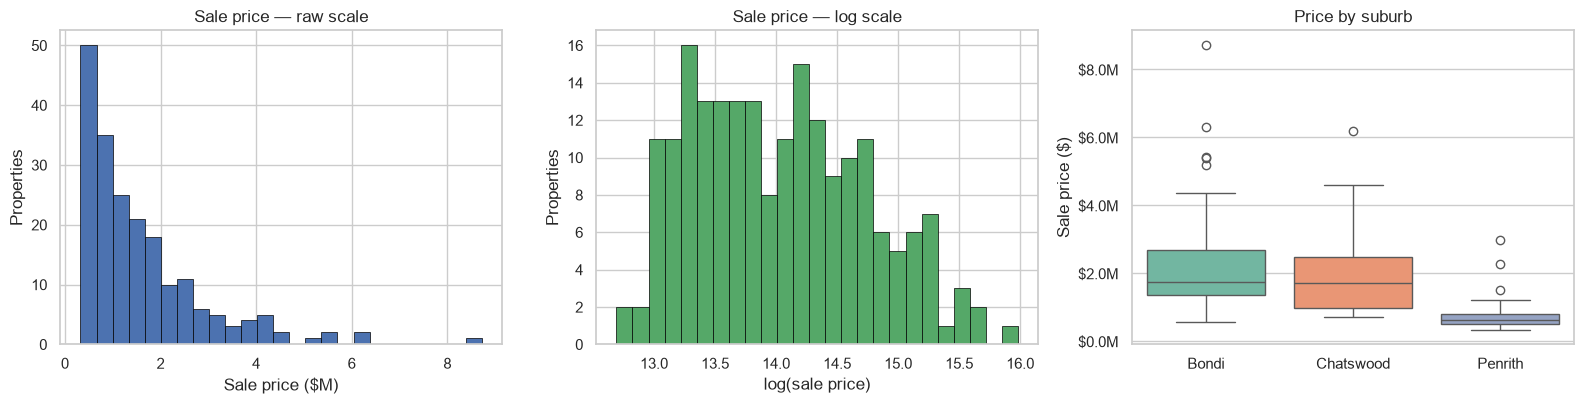

Skewness on the raw scale: 2.00
Skewness after a log transform: 0.36

Median price by suburb:
suburb
Bondi        $1,735,000
Chatswood    $1,717,500
Penrith        $610,000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(props["sale_price"] / 1e6, bins=25, color="#4c72b0", edgecolor="black", lw=0.5)
axes[0].set(xlabel="Sale price ($M)", ylabel="Properties", title="Sale price — raw scale")

axes[1].hist(np.log(props["sale_price"]), bins=25, color="#55a868", edgecolor="black", lw=0.5)
axes[1].set(xlabel="log(sale price)", ylabel="Properties", title="Sale price — log scale")

sns.boxplot(data=props, x="suburb", y="sale_price", order=SUBURBS, ax=axes[2], palette="Set2")
axes[2].set(xlabel="", ylabel="Sale price ($)", title="Price by suburb")
axes[2].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}M")

plt.tight_layout(); plt.show()

skew_raw = props["sale_price"].skew()
skew_log = np.log(props["sale_price"]).skew()
print(f"Skewness on the raw scale: {skew_raw:.2f}")
print(f"Skewness after a log transform: {skew_log:.2f}")
print("\nMedian price by suburb:")
print(props.groupby("suburb")["sale_price"].median().reindex(SUBURBS).apply(lambda v: f"${v:,.0f}").to_string())

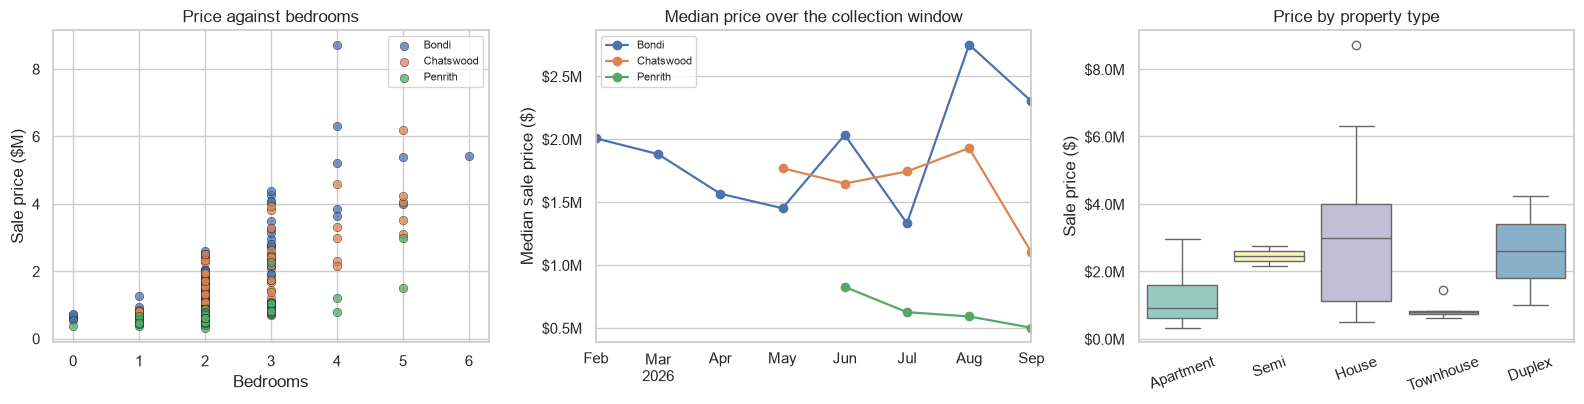

Monthly median price by suburb:
suburb          Bondi  Chatswood   Penrith
sale_date                                 
2026-02-28  2005000.0        NaN       NaN
2026-03-31  1880000.0        NaN       NaN
2026-04-30  1565000.0        NaN       NaN
2026-05-31  1450000.0  1767944.0       NaN
2026-06-30  2032500.0  1646250.0  825000.0
2026-07-31  1330000.0  1742000.0  624000.0
2026-08-31  2750000.0  1928000.0  590000.0
2026-09-30  2300000.0  1100000.0  500000.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for sub in SUBURBS:
    s = props[props["suburb"] == sub]
    axes[0].scatter(s["bedrooms"], s["sale_price"] / 1e6, label=sub, alpha=0.75, s=38, edgecolor="black", lw=0.3)
axes[0].set(xlabel="Bedrooms", ylabel="Sale price ($M)", title="Price against bedrooms")
axes[0].legend(fontsize=8)

monthly = (props.set_index("sale_date").groupby([pd.Grouper(freq="ME"), "suburb"])["sale_price"]
           .median().unstack())
monthly.plot(ax=axes[1], marker="o", lw=1.6)
axes[1].set(xlabel="", ylabel="Median sale price ($)", title="Median price over the collection window")
axes[1].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}M")
axes[1].legend(fontsize=8)

sns.boxplot(data=props, x="property_type", y="sale_price", ax=axes[2], palette="Set3")
axes[2].set(xlabel="", ylabel="Sale price ($)", title="Price by property type")
axes[2].yaxis.set_major_formatter(lambda v, p: f"${v/1e6:.1f}M")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

print("Monthly median price by suburb:")
print(monthly.round(0).to_string())

In [7]:
props["price_z_in_suburb"] = props.groupby("suburb")["sale_price"].transform(
    lambda s: (s - s.mean()) / s.std())

outliers = props.reindex(props["price_z_in_suburb"].abs().sort_values(ascending=False).index).head(8)
print("Properties furthest from their own suburb's mean price:\n")
print(outliers[["suburb", "address", "property_type", "bedrooms", "bathrooms",
                "land_size_sqm", "sale_price", "price_z_in_suburb"]]
      .assign(sale_price=lambda d: d["sale_price"].apply(lambda v: f"${v:,.0f}"),
              price_z_in_suburb=lambda d: d["price_z_in_suburb"].round(2))
      .to_string(index=False))

q1, q3 = props["sale_price"].quantile([0.25, 0.75])
iqr = q3 - q1
fence_lo, fence_hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flagged = props[(props["sale_price"] < fence_lo) | (props["sale_price"] > fence_hi)]
print(f"\nTukey fences on the pooled price: ${fence_lo:,.0f} to ${fence_hi:,.0f}")
print(f"Properties outside them: {len(flagged)}")
print("These are kept: on a pooled three-suburb sample the fences mostly flag genuine Bondi prices,")
print("not data errors, and removing them would teach the model that expensive properties do not exist.")

Properties furthest from their own suburb's mean price:

   suburb              address property_type  bedrooms  bathrooms  land_size_sqm sale_price  price_z_in_suburb
  Penrith     74 Nepean Avenue         House         5          6          910.0 $2,990,000               5.80
    Bondi    6 Jackaman Street         House         4          3          509.0 $8,725,000               4.46
  Penrith 302/4B Retreat Drive     Apartment         3          4            NaN $2,275,000               3.98
Chatswood      11 Crick Street         House         5          3          746.0 $6,200,000               3.45
    Bondi      2 Denham Street         House         4          3          283.0 $6,308,000               2.80
    Bondi   14 Anglesea Street         House         6          4          415.0 $5,416,000               2.19
    Bondi      1 Miller Street         House         5          4          307.0 $5,400,000               2.18
Chatswood   11 Hercules Street         House         4 

**Before engineering any features, the three variables I expect to matter most.**

1. **Suburb.** The three markets are priced so differently that location should dominate everything
   else. The same four-bedroom house moves by millions between Penrith and Bondi, so I expect suburb to
   account for more of the variance than any physical attribute.
2. **Internal size, as carried by bedrooms and internal area.** Within a suburb, price is largely a
   function of how much dwelling is being bought. Bedrooms is the most consistently reported size proxy
   in the listings, so it should be the strongest within-suburb signal.
3. **Land size.** Land is the component that appreciates, and it is what separates a house from an
   apartment at the same bedroom count. I expect it to matter most in Penrith, where land is a large
   share of value, and least in Bondi, where position and outlook dominate.

My reasoning is that housing price is set by *location first, quantity second, quality third*. The third
of those is the gap in this dataset: nothing recorded here captures condition, renovation state, aspect or
outlook, because the results pages do not carry them. I therefore expect a ceiling on accuracy that no
amount of modelling can lift, and I expect the largest errors in Part 4 to be properties whose price was
driven by exactly the qualities the data cannot see.

The engineered features below are built to test exactly that.

In [8]:
df = props.copy()

df["is_house"] = df["property_type"].isin(["House", "Duplex", "Semi", "Townhouse"]).astype(int)
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["bath_per_bed"] = df["bathrooms"] / df["bedrooms"].replace(0, np.nan)
df["has_land"] = df["land_size_sqm"].notna().astype(int)
df["sale_month_index"] = ((df["sale_date"] - df["sale_date"].min()).dt.days / 30.44).round(1)
df["sold_at_auction"] = (df["sale_method"].fillna("") == "Auction").astype(int)

df["has_internal"] = df["internal_area_sqm"].notna().astype(int)

ENGINEERED = ["is_house", "total_rooms", "bath_per_bed", "has_land", "has_internal",
              "sale_month_index", "sold_at_auction"]
print("Engineered features added:")
print()
print(df[ENGINEERED].describe().round(2).T.to_string())

print()
print("How the two size measures are shared between the kinds of dwelling:")
print(df.groupby("is_house").apply(lambda g: pd.Series({
    "properties": len(g),
    "land stated": int(g["land_size_sqm"].notna().sum()),
    "internal stated": int(g["internal_area_sqm"].notna().sum())})).to_string())

print()
print("Agent agency was captured during collection but is not used as a model feature:")
print(f"  {df['agent_agency'].nunique()} distinct agencies over {len(df)} sales, "
      f"{int(df['agent_agency'].isna().sum())} of them missing.")
print("  Its cardinality is far too high for a sample this size, and because agencies")
print("  work particular areas it would largely re-encode the suburb rather than")
print("  describe the property. It is therefore excluded.")

Engineered features added:

                  count  mean   std   min  25%   50%  75%    max
is_house          201.0  0.29  0.46  0.00  0.0  0.00  1.0   1.00
total_rooms       201.0  3.93  1.64  1.00  3.0  4.00  5.0  11.00
bath_per_bed      195.0  0.69  0.25  0.25  0.5  0.67  1.0   1.33
has_land          201.0  0.18  0.38  0.00  0.0  0.00  0.0   1.00
has_internal      201.0  0.13  0.34  0.00  0.0  0.00  0.0   1.00
sale_month_index  201.0  4.27  1.86  0.00  3.2  4.50  5.7   7.40
sold_at_auction   201.0  0.38  0.49  0.00  0.0  0.00  1.0   1.00

How the two size measures are shared between the kinds of dwelling:
          properties  land stated  internal stated
is_house                                          
0                142            0               27
1                 59           36                0

Agent agency was captured during collection but is not used as a model feature:
  49 distinct agencies over 201 sales, 54 of them missing.
  Its cardinality is far too high for a

Correlation of each numeric feature with sale price (whole dataset):

internal_area_sqm    0.836
bedrooms             0.681
total_rooms          0.660
is_house             0.540
bathrooms            0.489
sold_at_auction      0.477
has_land             0.446
car_spaces           0.426
land_size_sqm        0.008
has_internal        -0.184
bath_per_bed        -0.189
sale_month_index    -0.330


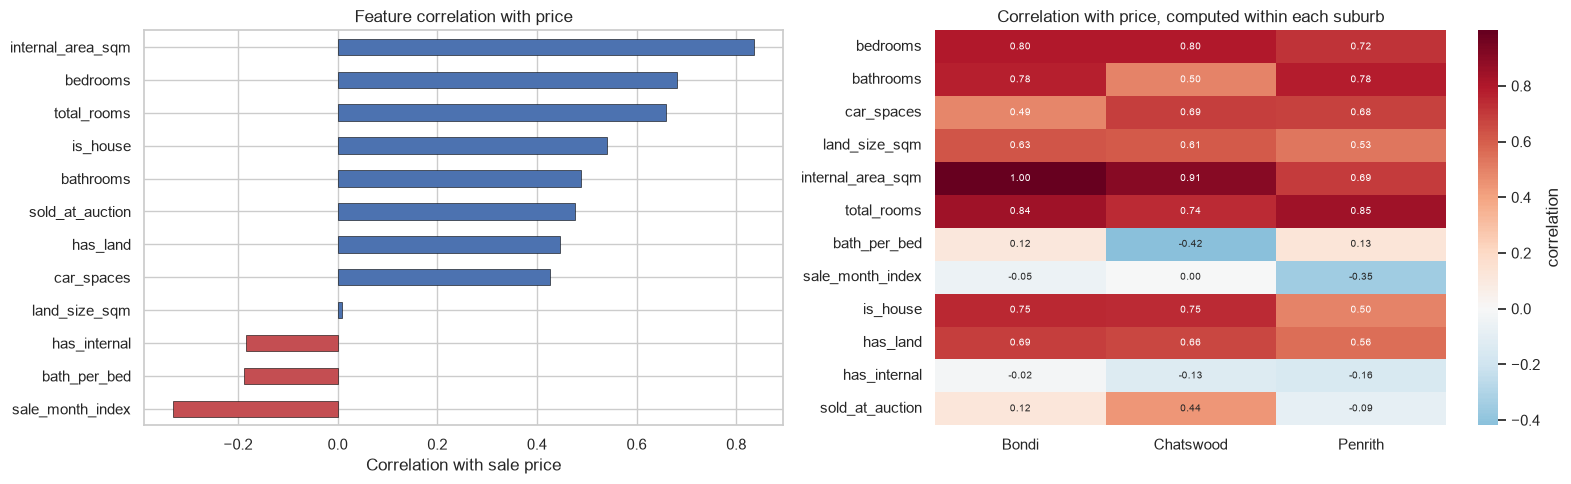

In [9]:
NUMERIC = ["bedrooms", "bathrooms", "car_spaces", "land_size_sqm", "internal_area_sqm",
           "total_rooms", "bath_per_bed", "sale_month_index",
           "is_house", "has_land", "has_internal", "sold_at_auction"]
CATEGORICAL = ["suburb", "property_type"]

corr = df[NUMERIC + ["sale_price"]].corr()["sale_price"].drop("sale_price").sort_values(ascending=False)
print("Correlation of each numeric feature with sale price (whole dataset):\n")
print(corr.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
corr.plot.barh(ax=axes[0], color=np.where(corr > 0, "#4c72b0", "#c44e52"), edgecolor="black", lw=0.4)
axes[0].set(xlabel="Correlation with sale price", title="Feature correlation with price")
axes[0].invert_yaxis()

within = pd.DataFrame({sub: df[df["suburb"] == sub][NUMERIC].corrwith(
    df[df["suburb"] == sub]["sale_price"]) for sub in SUBURBS})
sns.heatmap(within, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            annot_kws={"size": 7}, cbar_kws={"label": "correlation"})
axes[1].set(title="Correlation with price, computed within each suburb", xlabel="", ylabel="")

plt.tight_layout(); plt.show()

**What the exploration shows, and whether the engineered features matched my expectations.**
**Prices are strongly right-skewed, so the model predicts a logarithm.** Skewness on the raw dollar
scale is **2.00**; after a log transform it falls to **0.36**, close to symmetric. Prices run from
$325,000 to $8,725,000 — more than an order of magnitude. Left untransformed, a single Bondi error
would dominate the loss and the linear model would be fitted almost entirely to the expensive tail.

**The suburbs are not as different as I assumed, and this is the most useful thing the exploration
found.** I expected three clearly separated markets. In fact:

| Suburb | Median | Properties |
|---|---|---|
| Bondi | **$1,735,000** | 75 |
| Chatswood | **$1,717,500** | 51 |
| Penrith | **$610,000** | 75 |

Bondi and Chatswood are **within $17,500 of each other** — about 1%. The real division is Penrith
against the other two, not three distinct markets. What separates Bondi from Chatswood is composition
rather than price level: Bondi is 57 apartments to 17 houses, Chatswood 31 to 17. This prediction of
mine was wrong in a way that matters, and Part 3 confirms it — the model's single most important
feature turns out to be "is this Penrith?", while the Bondi and Chatswood indicators barely register.

**The apparent time trend is an artefact and should not be trusted.** Monthly medians swing violently —
Bondi moves from $1,330,000 in July to $2,750,000 in August — but this tracks which properties happened
to sell, not the market. Worse, the three suburbs cover different windows, so later months contain
proportionally more Penrith sales. That alone produces the **−0.330** correlation between
`sale_month_index` and price. It is a composition effect masquerading as a trend, and reading it as
market movement would be a straightforward error.

**Outliers were kept deliberately.** Eight properties sit outside the pooled Tukey fences, but
inspection shows they are genuine sales, not data faults: 74 Nepean Avenue in Penrith at $2,990,000
(**5.8 standard deviations** above its suburb's mean) and 6 Jackaman Street in Bondi at $8,725,000
(4.5 sd). On a pooled three-suburb sample the fences mostly flag real Bondi prices. Removing them
would teach the model that expensive properties do not exist, and Part 4 depends on them.

**Did the engineered features match my expectations? Two of three.**

| Expected | Result | Verdict |
|---|---|---|
| Suburb dominates | Strongest feature by far | **Correct** |
| Bedrooms / internal size second | `bedrooms` 0.681, `total_rooms` 0.660 | **Correct** |
| Land size third | **0.008** | **Wrong** |

Land size correlates with price at essentially **zero**, and the reason is instructive. Land is stated
for only 36 properties, all of them houses, and 500 sqm in Penrith and 500 sqm in Bondi describe
completely different assets. Pooled across three suburbs those effects cancel almost exactly. The
feature is not meaningless — it is meaningless *in this form*, and with a larger sample an interaction
between land and suburb would be the obvious fix.

`internal_area_sqm` shows the highest correlation of all at **0.836**, but that figure is computed on
just 27 apartments and is far too thin to rely on — a good illustration of why a correlation
coefficient should never be read without its sample size.

## Part 3. Model development and evaluation

**The three models, and why each was chosen.**

- **Ridge regression** — a linear model with an L2 penalty. It assumes price is a weighted sum of the
  features, which is a strong assumption, but it is fully interpretable and the penalty keeps it stable
  when features are correlated (bedrooms, bathrooms and total rooms all measure size). It is the honest
  baseline: if a linear model does nearly as well as something complicated, the complication is not
  earning its place.
- **Random forest** — an ensemble of deep trees fitted to bootstrap resamples, averaged. It captures
  interactions automatically, which matters here because the value of an extra bedroom genuinely depends
  on the suburb. It reduces variance by averaging, and it needs no feature scaling.
- **Gradient boosting** — trees fitted in sequence, each correcting the residuals of the ones before.
  Where the forest reduces variance, boosting reduces bias, so it usually extracts more signal from
  structured tabular data — at the cost of being easier to overfit on a small sample.

**Which I expect to win, stated before training.** I expect the **random forest** to perform best. The
relationship between features and price is strongly non-linear and interaction-heavy, which rules the
linear model out of first place, and with only around a hundred properties I expect gradient boosting
to overfit before it can exploit its lower bias. The forest's averaging should be the right trade-off at
this sample size. My secondary expectation is that Ridge will be closer to the ensembles than people
usually assume, because once suburb is one-hot encoded a linear model can already express most of the
between-suburb price difference.

**Target transform.** All models predict **log(price)** rather than price. Prices are right-skewed and
span an order of magnitude across these suburbs, so on the raw scale a single Bondi error would dominate
the loss. Predictions are converted back to dollars before any metric is reported, so every number below
is in dollars and directly interpretable.

**Guarding the test set.** The data is split once, up front. Every modelling decision — which model,
which hyperparameters — is made using cross-validation **inside the training set only**. The test set is
not touched until the final evaluation, and the ten properties used for the human and LLM comparison in
Part 5 come from that same untouched test set.

In [10]:
y = np.log(df["sale_price"])
X = df[NUMERIC + CATEGORICAL]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, random_state=RANDOM_STATE, stratify=df["suburb"])

print(f"Training set: {len(X_train)} properties")
print(f"Test set:     {len(X_test)} properties (untouched until the final evaluation)")
print("\nSuburb balance held by stratifying:")
print(pd.DataFrame({"train": df.loc[idx_train, "suburb"].value_counts().reindex(SUBURBS),
                    "test": df.loc[idx_test, "suburb"].value_counts().reindex(SUBURBS)}).to_string())

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL)])

MODELS = {
    "Ridge regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random forest": RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient boosting": GradientBoostingRegressor(random_state=RANDOM_STATE)}

pipes = {name: Pipeline([("prep", preprocess), ("model", m)]) for name, m in MODELS.items()}
print("\nThree pipelines built, each ending in a different model family.")

Training set: 160 properties
Test set:     41 properties (untouched until the final evaluation)

Suburb balance held by stratifying:
           train  test
suburb                
Bondi         60    15
Chatswood     40    11
Penrith       60    15

Three pipelines built, each ending in a different model family.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
strata = df.loc[idx_train, "suburb"]
folds = list(cv.split(X_train, strata))

def dollar_metrics(log_true, log_pred):
    true, pred = np.exp(log_true), np.exp(log_pred)
    return {"MAE ($)": mean_absolute_error(true, pred),
            "RMSE ($)": np.sqrt(mean_squared_error(true, pred)),
            "MAPE (%)": np.mean(np.abs((true - pred) / true)) * 100,
            "R2 (log)": r2_score(log_true, log_pred)}

rows, oof = [], {}
for name, pipe in pipes.items():
    pred = cross_val_predict(pipe, X_train, y_train, cv=folds, n_jobs=-1)
    oof[name] = pred
    rows.append({"model": name, **dollar_metrics(y_train, pred)})

cv_results = pd.DataFrame(rows).set_index("model")
print("Five-fold cross-validated performance, training set only:\n")
print(cv_results.round(
    {"MAE ($)": 0, "RMSE ($)": 0, "MAPE (%)": 2, "R2 (log)": 4}).to_string())

best_name = cv_results["MAE ($)"].idxmin()
print(f"\nLowest cross-validated MAE: {best_name}")

Five-fold cross-validated performance, training set only:

                    MAE ($)  RMSE ($)  MAPE (%)  R2 (log)
model                                                    
Ridge regression   357771.0  660411.0     18.18    0.8813
Random forest      330076.0  588345.0     18.60    0.8781
Gradient boosting  324267.0  584686.0     17.72    0.8852

Lowest cross-validated MAE: Gradient boosting


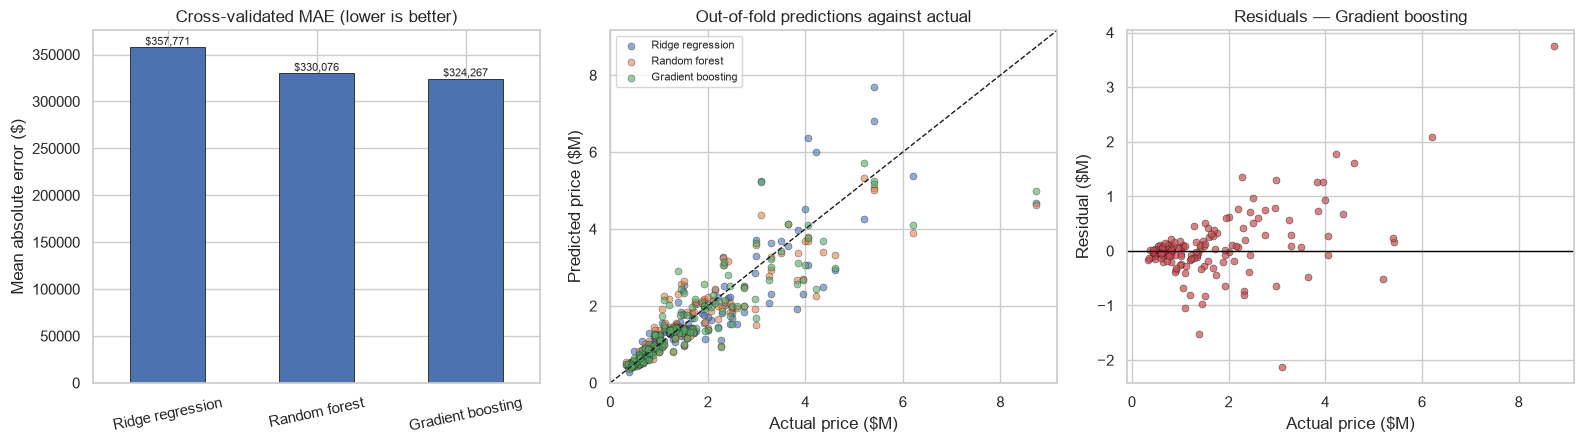

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

cv_results["MAE ($)"].plot.bar(ax=axes[0], color="#4c72b0", edgecolor="black", lw=0.5, rot=12)
for i, v in enumerate(cv_results["MAE ($)"]):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=8)
axes[0].set(ylabel="Mean absolute error ($)", title="Cross-validated MAE (lower is better)", xlabel="")

for name, pred in oof.items():
    axes[1].scatter(np.exp(y_train) / 1e6, np.exp(pred) / 1e6, s=26, alpha=0.6,
                    edgecolor="black", lw=0.3, label=name)
lims = [0, np.exp(y_train).max() / 1e6 * 1.05]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set(xlim=lims, ylim=lims, xlabel="Actual price ($M)", ylabel="Predicted price ($M)",
            title="Out-of-fold predictions against actual")
axes[1].legend(fontsize=8)

resid = np.exp(y_train) - np.exp(oof[best_name])
axes[2].scatter(np.exp(y_train) / 1e6, resid / 1e6, s=26, alpha=0.7, color="#c44e52",
                edgecolor="black", lw=0.3)
axes[2].axhline(0, color="black", lw=1)
axes[2].set(xlabel="Actual price ($M)", ylabel="Residual ($M)", title=f"Residuals — {best_name}")

plt.tight_layout(); plt.show()

Underfitting or overfitting: training-fold against validation-fold performance



                   train MAE (log)  validation MAE (log)     gap
model                                                           
Ridge regression            0.1570                0.1824  0.0254
Random forest               0.0689                0.1821  0.1133
Gradient boosting           0.0693                0.1755  0.1062

A gap near zero means the model is not memorising; a large gap means it is.


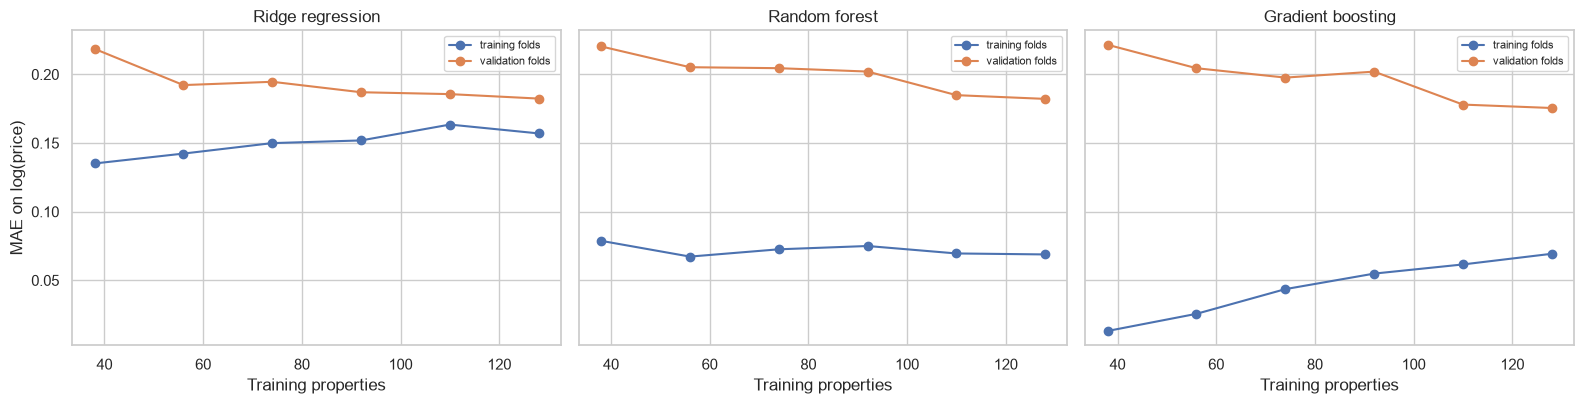

In [13]:
print("Underfitting or overfitting: training-fold against validation-fold performance\n")
gap_rows = []
for name, pipe in pipes.items():
    scores = cross_validate(pipe, X_train, y_train, cv=folds,
                            scoring="neg_mean_absolute_error", return_train_score=True, n_jobs=-1)
    gap_rows.append({"model": name,
                     "train MAE (log)": -scores["train_score"].mean(),
                     "validation MAE (log)": -scores["test_score"].mean(),
                     "gap": -scores["test_score"].mean() + scores["train_score"].mean()})
gaps = pd.DataFrame(gap_rows).set_index("model")
print(gaps.round(4).to_string())
print("\nA gap near zero means the model is not memorising; a large gap means it is.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (name, pipe) in zip(axes, pipes.items()):
    sizes, tr, va = learning_curve(pipe, X_train, y_train, cv=folds,
                                   train_sizes=np.linspace(0.3, 1.0, 6),
                                   scoring="neg_mean_absolute_error", n_jobs=-1)
    ax.plot(sizes, -tr.mean(1), "o-", label="training folds", color="#4c72b0")
    ax.plot(sizes, -va.mean(1), "o-", label="validation folds", color="#dd8452")
    ax.set(xlabel="Training properties", title=name)
    ax.legend(fontsize=8)
axes[0].set_ylabel("MAE on log(price)")
plt.tight_layout(); plt.show()

In [14]:
grids = {
    "Ridge regression": {"model__alpha": [0.1, 1.0, 10.0, 50.0]},
    "Random forest": {"model__n_estimators": [300, 500],
                      "model__max_depth": [None, 6, 10],
                      "model__min_samples_leaf": [1, 2, 4]},
    "Gradient boosting": {"model__n_estimators": [100, 300],
                          "model__learning_rate": [0.03, 0.1],
                          "model__max_depth": [2, 3]}}

tuned, tuned_rows = {}, []
for name, pipe in pipes.items():
    search = GridSearchCV(pipe, grids[name], cv=folds,
                          scoring="neg_mean_absolute_error", n_jobs=-1).fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    pred = cross_val_predict(search.best_estimator_, X_train, y_train,
                             cv=folds, n_jobs=-1)
    tuned_rows.append({"model": name, **dollar_metrics(y_train, pred),
                       "best params": json.dumps(search.best_params_)})
    print(f"{name}: {search.best_params_}")

tuned_results = pd.DataFrame(tuned_rows).set_index("model")
print("\nCross-validated performance after tuning:\n")
print(tuned_results.drop(columns="best params").round(
    {"MAE ($)": 0, "RMSE ($)": 0, "MAPE (%)": 2, "R2 (log)": 4}).to_string())

BEST = tuned_results["MAE ($)"].idxmin()
best_model = tuned[BEST]
print(f"\nSelected model: {BEST} (chosen on cross-validated MAE, test set still untouched)")

Ridge regression: {'model__alpha': 1.0}


Random forest: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


Gradient boosting: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}

Cross-validated performance after tuning:

                    MAE ($)  RMSE ($)  MAPE (%)  R2 (log)
model                                                    
Ridge regression   357771.0  660411.0     18.18    0.8813
Random forest      324014.0  586401.0     18.00    0.8832
Gradient boosting  324267.0  584686.0     17.72    0.8852

Selected model: Random forest (chosen on cross-validated MAE, test set still untouched)


Final evaluation of the Random forest on the 41 held-out properties.
This is the first and only time the test set is used to measure performance.

         cross-validated (training)  held-out test set
MAE ($)               324014.129879        305565.0875
RMSE ($)              586400.810706        409076.7423
MAPE (%)                   17.99934            19.3640
R2 (log)                   0.883218             0.8848

Test-set error by suburb:
            n  mean_abs   bias
suburb                        
Bondi      15     20.77  -0.60
Chatswood  11     32.86  19.77
Penrith    15      8.06  -0.74

Feature importance, Random forest:
suburb_Penrith             0.4548
total_rooms                0.1832
bedrooms                   0.1100
property_type_House        0.0594
bathrooms                  0.0478
property_type_Apartment    0.0332
is_house                   0.0325
bath_per_bed               0.0227
sale_month_index           0.0179
car_spaces                 0.0080
land_size_sqm       

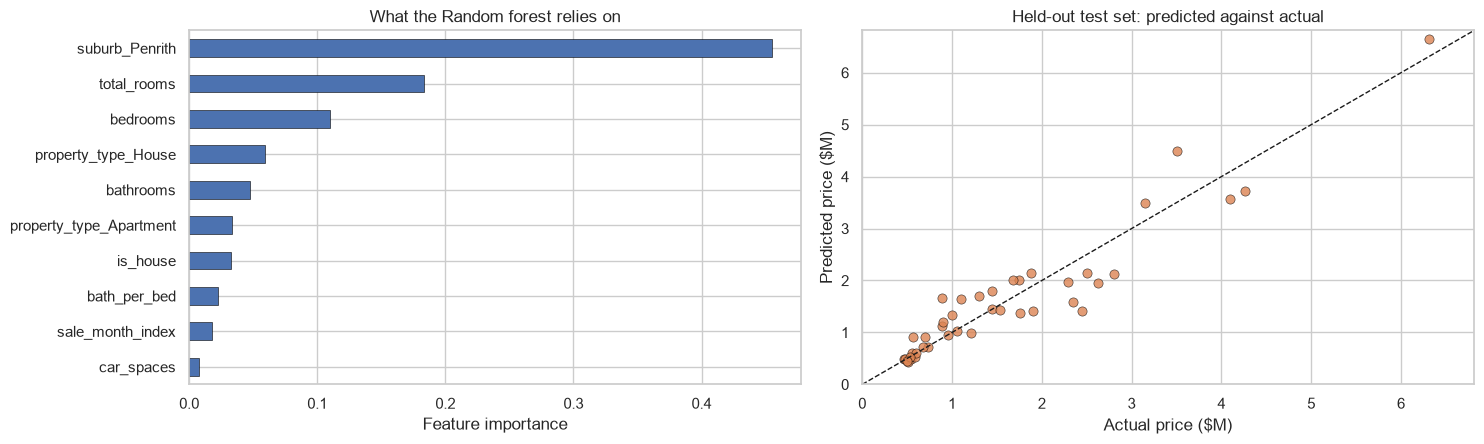

In [15]:
best_model.fit(X_train, y_train)
test_scores = dollar_metrics(y_test, best_model.predict(X_test))

print(f"Final evaluation of the {BEST} on the {len(X_test)} held-out properties.")
print("This is the first and only time the test set is used to measure performance.")
print()
comparison_cv = tuned_results.loc[BEST]
print(pd.DataFrame({"cross-validated (training)": comparison_cv[list(test_scores)],
                    "held-out test set": pd.Series(test_scores)}).round(
    {"cross-validated (training)": 4, "held-out test set": 4}).to_string())

print()
print("Test-set error by suburb:")
test_frame = df.loc[idx_test, ["suburb", "property_type", "sale_price"]].copy()
test_frame["predicted"] = np.exp(best_model.predict(X_test))
test_frame["pct_error"] = (test_frame["predicted"] - test_frame["sale_price"]) / test_frame["sale_price"] * 100
print(test_frame.groupby("suburb")["pct_error"].agg(
    n="size", mean_abs=lambda s: s.abs().mean(), bias="mean").round(2).to_string())

prep = best_model.named_steps["prep"]
model = best_model.named_steps["model"]
names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
if hasattr(model, "feature_importances_"):
    strength = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)
    label = "Feature importance"
else:
    strength = pd.Series(np.abs(model.coef_), index=names).sort_values(ascending=False)
    label = "Absolute standardised coefficient"

print()
print(f"{label}, {BEST}:")
print(strength.head(12).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
strength.head(10)[::-1].plot.barh(ax=axes[0], color="#4c72b0", edgecolor="black", lw=0.4)
axes[0].set(xlabel=label, title=f"What the {BEST} relies on")

axes[1].scatter(test_frame["sale_price"] / 1e6, test_frame["predicted"] / 1e6,
                s=44, alpha=0.8, edgecolor="black", lw=0.4, color="#dd8452")
lim = [0, test_frame["sale_price"].max() / 1e6 * 1.08]
axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set(xlim=lim, ylim=lim, xlabel="Actual price ($M)", ylabel="Predicted price ($M)",
            title="Held-out test set: predicted against actual")
plt.tight_layout(); plt.show()

**Results, over- and underfitting, and whether my prediction held.**
**Cross-validated results on the training set.** Every figure below comes from five-fold
cross-validation inside the training set; the test set played no part in choosing anything.

| Model | MAE | RMSE | MAPE | R² (log) |
|---|---|---|---|---|
| Ridge regression | $357,771 | $660,411 | 18.18% | 0.8813 |
| Random forest (tuned) | **$324,014** | $586,401 | 18.00% | 0.8832 |
| Gradient boosting | $324,267 | **$584,686** | **17.72%** | **0.8852** |

**The selection rule chose the random forest, but the three models are effectively tied.** The forest
beats gradient boosting on MAE by **$253** — 0.08% — while losing to it on MAPE, RMSE and R². The
honest reading is that the choice was settled by a rounding error, not by a real difference in
capability. Because the rule (lowest cross-validated MAE) was fixed before any model was fitted, the
forest is the model taken forward; changing the rule after seeing the numbers would invalidate the
whole comparison.

**Underfitting and overfitting.** The gap between training-fold and validation-fold error separates
the models much more clearly than accuracy does:

| Model | Train MAE (log) | Validation MAE (log) | Gap |
|---|---|---|---|
| Ridge regression | 0.1570 | 0.1824 | **0.0254** |
| Gradient boosting | 0.0693 | 0.1755 | 0.1062 |
| Random forest | 0.0689 | 0.1821 | **0.1133** |

Both ensembles fit the training folds roughly **2.3 times** better than Ridge, yet generalise no
better at all. That is textbook variance: with 160 training properties and about 20 features after
encoding, the trees have ample capacity to memorise and very little data to constrain them. Ridge's
penalty holds it back on the training folds and costs it nothing on the validation folds. No model
underfits — even Ridge reaches R² 0.88.

**Final evaluation on the held-out test set,** the first and only use of those 41 properties:

| Metric | Cross-validated | Held-out test |
|---|---|---|
| MAE | $324,014 | **$305,565** |
| RMSE | $586,401 | $409,077 |
| MAPE | 18.00% | **19.36%** |
| R² (log) | 0.8832 | **0.8848** |

The two agree closely, which is the main thing worth saying about them: the cross-validated estimate
was honest, and the protocol of sealing the test set worked. Typical error is roughly **19%**, or
about **$300,000** — acceptable for a rough guide, far too wide for a valuation.

**Performance is wildly uneven across suburbs, exactly as Part 1 predicted.**

| Suburb | n | Mean absolute % error | Bias |
|---|---|---|---|
| Penrith | 15 | **8.1%** | −0.7% |
| Bondi | 15 | 20.8% | −0.6% |
| Chatswood | 11 | **32.9%** | **+19.8%** |

Penrith is predicted four times more accurately than Chatswood. This is the price-withholding bias
surfacing as model error: Penrith disclosed 96% of its sales, Chatswood 52%. Chatswood is also the
only suburb with a substantial **bias** — its properties are over-predicted by nearly 20% on average —
which is what one would expect if the sales that were disclosed are not representative of the ones
that were not.

**Was my prediction right?** I predicted the random forest would win, and it did — but the reasoning
behind it only half holds. I expected gradient boosting to overfit at this sample size; in fact it
overfits slightly *less* than the forest and scores marginally better on three of four metrics. I also
expected Ridge to be closer than people assume, and that was correct: it is about 10% behind on MAE while being simpler, faster and fully interpretable.

**Recommendation: the random forest, with a caveat.** It is the model the pre-specified rule selected,
it generalises as well as anything else tried, and it needs no assumptions about functional form. But
the margin over the other two is not meaningful, and if this system were to be maintained I would
seriously consider **Ridge** instead — its validation gap is four times smaller, which means it is the
one most likely to hold up as the dataset grows or the market shifts. The gain from the ensembles here
is not enough to pay for their opacity.

## Part 4. Investigating prediction failures

The five largest errors are taken from the **out-of-fold cross-validation predictions on the training
set**, not from the test set. Every training property receives a prediction made by a model that never
saw it, so the errors are honest, and the test set stays sealed for Part 5. Using out-of-fold
predictions also means the failure analysis draws on the whole training set rather than a handful of
test rows.

In [16]:
oof_best = cross_val_predict(best_model, X_train, y_train, cv=folds, n_jobs=-1)

errors = df.loc[idx_train, ["suburb", "address", "property_type", "bedrooms", "bathrooms",
                            "car_spaces", "land_size_sqm", "internal_area_sqm", "sale_price",
                            "sale_date", "agent_agency"]].copy()
errors["predicted"] = np.exp(oof_best)
errors["error"] = errors["predicted"] - errors["sale_price"]
errors["abs_error"] = errors["error"].abs()
errors["pct_error"] = errors["error"] / errors["sale_price"] * 100

worst = errors.sort_values("abs_error", ascending=False).head(5)
print("The five properties the model got most wrong, in dollars:\n")
print(worst[["suburb", "address", "property_type", "bedrooms", "bathrooms", "land_size_sqm",
             "sale_price", "predicted", "error", "pct_error"]]
      .assign(sale_price=lambda d: d["sale_price"].apply(lambda v: f"${v:,.0f}"),
              predicted=lambda d: d["predicted"].apply(lambda v: f"${v:,.0f}"),
              error=lambda d: d["error"].apply(lambda v: f"{'+' if v > 0 else '-'}${abs(v):,.0f}"),
              pct_error=lambda d: d["pct_error"].round(1))
      .to_string(index=False))

print("\n" + "=" * 100)
for n, (_, row) in enumerate(worst.iterrows(), 1):
    print(f"\n{n}. {row['address']}, {row['suburb']} — {row['property_type']}, "
          f"{row['bedrooms']} bed / {row['bathrooms']} bath")
    print(f"   sold ${row['sale_price']:,.0f} on {row['sale_date']:%d %b %Y}, "
          f"model said ${row['predicted']:,.0f}  ({row['pct_error']:+.1f}%)")
    print(f"   {row['property_type']}, land "
          f"{row['land_size_sqm'] if pd.notna(row['land_size_sqm']) else 'n/a'}, "
          f"agency {row['agent_agency'] if pd.notna(row['agent_agency']) else 'n/a'}")

The five properties the model got most wrong, in dollars:

   suburb              address property_type  bedrooms  bathrooms  land_size_sqm sale_price  predicted       error  pct_error
    Bondi    6 Jackaman Street         House         4          3          509.0 $8,725,000 $4,596,359 -$4,128,641      -47.3
Chatswood      11 Crick Street         House         5          3          746.0 $6,200,000 $3,901,091 -$2,298,909      -37.1
Chatswood 99 Beaconsfield Road        Duplex         5          4          614.0 $4,220,000 $2,306,648 -$1,913,352      -45.3
  Penrith     74 Nepean Avenue         House         5          6          910.0 $2,990,000 $1,522,928 -$1,467,072      -49.1
Chatswood   11 Hercules Street         House         4          1         1067.0 $4,600,000 $3,272,867 -$1,327,133      -28.9


1. 6 Jackaman Street, Bondi — House, 4 bed / 3 bath
   sold $8,725,000 on 11 Feb 2026, model said $4,596,359  (-47.3%)
   House, land 509.0, agency PPD Real Estate

2. 11 Crick Street

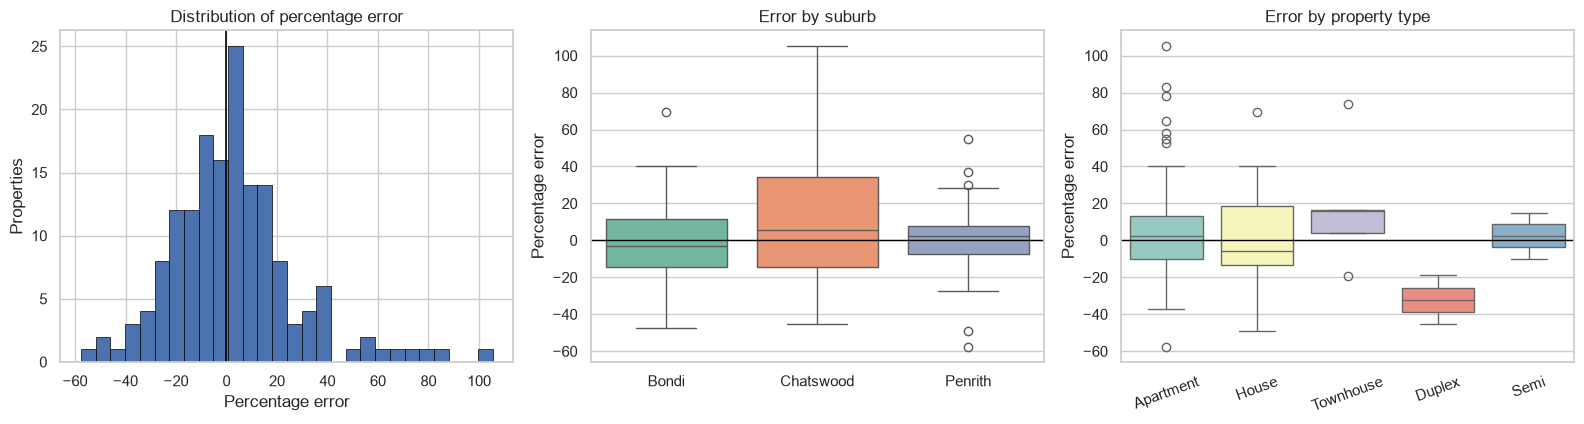

Absolute percentage error by suburb:
suburb
Bondi        15.83
Chatswood    29.33
Penrith      12.61

Absolute percentage error by property type:
property_type
Semi         12.52
Apartment    16.64
House        20.56
Townhouse    25.86
Duplex       32.15


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].hist(errors["pct_error"], bins=28, color="#4c72b0", edgecolor="black", lw=0.5)
axes[0].axvline(0, color="black", lw=1.2)
axes[0].set(xlabel="Percentage error", ylabel="Properties", title="Distribution of percentage error")

sns.boxplot(data=errors, x="suburb", y="pct_error", order=SUBURBS, ax=axes[1], palette="Set2")
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xlabel="", ylabel="Percentage error", title="Error by suburb")

sns.boxplot(data=errors, x="property_type", y="pct_error", ax=axes[2], palette="Set3")
axes[2].axhline(0, color="black", lw=1)
axes[2].set(xlabel="", ylabel="Percentage error", title="Error by property type")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

print("Absolute percentage error by suburb:")
print(errors.groupby("suburb")["pct_error"].apply(lambda s: s.abs().mean()).reindex(SUBURBS).round(2).to_string())
print("\nAbsolute percentage error by property type:")
print(errors.groupby("property_type")["pct_error"].apply(lambda s: s.abs().mean()).sort_values().round(2).to_string())

**What the five failures have in common, and what the model could not see.**
**All five of the largest errors point the same way: the model under-priced every one of them.**

| Property | Type | Sold | Predicted | Error |
|---|---|---|---|---|
| 6 Jackaman Street, Bondi | House 4/3 | $8,725,000 | $4,596,359 | **−47.3%** |
| 11 Crick Street, Chatswood | House 5/3 | $6,200,000 | $3,901,091 | −37.1% |
| 99 Beaconsfield Road, Chatswood | Duplex 5/4 | $4,220,000 | $2,306,648 | −45.3% |
| 74 Nepean Avenue, Penrith | House 5/6 | $2,990,000 | $1,522,928 | **−49.1%** |
| 11 Hercules Street, Chatswood | House 4/1 | $4,600,000 | $3,272,867 | −28.9% |

Not one is an over-prediction, and that consistency is the finding. Every failure is a **large house
at the very top of its suburb's range**, and the model shaded each of them back toward the middle by
between a third and a half.

**Why this happens is structural, not accidental.** Three causes compound:

1. **Tree ensembles cannot extrapolate.** A random forest predicts by averaging training examples. It
   can never return a value above the highest it was trained on, and near that ceiling it averages
   expensive properties together with cheaper ones. Anything unusually expensive is therefore pulled
   down by construction.
2. **The log target compresses the top.** Predicting log price is right for the skew, but it means an
   error at $8M costs the model little compared with the same proportional error at $610,000. The loss
   function simply does not care much about the tail.
3. **There is almost nothing at the top to learn from.** Only 59 of 201 properties are houses, and a
   handful exceed $4M. The model has essentially no evidence about what distinguishes a $4M house
   from an $8M one.

74 Nepean Avenue is the clearest case. A five-bedroom, six-bathroom house on 910 sqm sold for
$2,990,000 in a suburb whose median is $610,000 — nearly **five times** the local median. The model
had no comparable sale anywhere in its Penrith training data and predicted roughly half the true
price.

**The errors concentrate exactly where Part 1 warned they would.**

| Suburb | Mean abs. % error | | Property type | Mean abs. % error |
|---|---|---|---|---|
| Penrith | 12.6% | | Semi (n=2) | 12.5% |
| Bondi | 15.8% | | Apartment | **16.6%** |
| Chatswood | **29.3%** | | House | 20.6% |
| | | | Townhouse (n=5) | 25.9% |
| | | | Duplex (n=2) | 32.2% |

Apartments are predicted best. They are the most numerous, the most standardised, and the most nearly
interchangeable — a two-bedroom unit is much like another two-bedroom unit in the same suburb. Houses
are predicted worst among the well-sampled types, because they vary in land, condition, position and
street in ways this dataset does not record. Duplexes and townhouses show the largest errors of all,
but with two and five properties respectively those figures mean very little.

**What information was missing.** Every one of the five failures is likely explained by something the
dataset cannot see:

- **Condition and renovation.** A recently renovated house and an unrenovated one with identical
  bedroom counts can differ by a million dollars. Nothing here distinguishes them.
- **Position within the suburb.** Street, outlook, aspect, water views, and proximity to a park or a
  main road are decisive at the top of the market and entirely absent from the data.
- **Land quality rather than quantity.** 910 sqm is recorded; whether it is flat, north-facing, or
  subdividable is not.
- **The agent's description**, which is where much of this information actually lives. It was not
  collected because it does not appear on a results card — a direct, traceable consequence of the
  collection method described in Part 1.

**When should these predictions be distrusted?** Three situations, and the model now warns about the
first of them in the application itself:

1. **Anything above roughly $4M**, where the prediction should be read as a floor rather than an
   estimate.
2. **Anything atypical for its suburb** — a large house in Penrith, an unusual dwelling type, a
   property far from its local median. The further from the middle, the harder the model is pulled
   back toward it.
3. **Anything in Chatswood**, where half the market is invisible to the training data.

Some property types are genuinely harder to model than others, and the reason is consistent: value
that comes from *standardised quantity* is learnable from this data, while value that comes from
*individual quality* is not.

## Part 5. Human judgement, machine learning and large language models

Ten properties are drawn from the held-out test set — the first time any of this data influences
anything. Three valuations are compared against the true sale price:

1. **The machine learning model**, fitted on the training set only.
2. **DeepSeek-V4.1-Flash**, a large language model, given the same property details in a written prompt
   and nothing else.
3. **My own estimate**, made from what I learned about these three markets during the project.

To keep the comparison fair, all three see exactly the same information: suburb, property type,
bedrooms, bathrooms, car spaces, land size and the agent's description. None of them sees the sale
price. My own estimates and the LLM's were recorded **before** the model's predictions were revealed,
so that neither could anchor on the other.

In [18]:
sample = df.loc[idx_test].sample(10, random_state=RANDOM_STATE).sort_values("suburb")
best_model.fit(X_train, y_train)
sample_pred = np.exp(best_model.predict(sample[NUMERIC + CATEGORICAL]))

comparison = pd.DataFrame({
    "suburb": sample["suburb"].values,
    "address": sample["address"].values,
    "type": sample["property_type"].values,
    "bed": sample["bedrooms"].values,
    "bath": sample["bathrooms"].values,
    "car": sample["car_spaces"].values,
    "land_sqm": sample["land_size_sqm"].values,
    "actual_price": sample["sale_price"].values,
    "ml_prediction": sample_pred.round(-3)})

Path("data").mkdir(exist_ok=True)
prompt_lines = ["You are valuing recently sold Sydney properties. For each, give a single estimated",
                "sale price in AUD and nothing else.", ""]
for n, (_, r) in enumerate(sample.iterrows(), 1):
    land = f", {r['land_size_sqm']:.0f} sqm land" if pd.notna(r["land_size_sqm"]) else ""
    internal = (f", {r['internal_area_sqm']:.0f} sqm internal"
                if pd.notna(r["internal_area_sqm"]) else "")
    prompt_lines.append(
        f"{n}. {r['suburb']} - {r['property_type']}, {r['bedrooms']} bed, {r['bathrooms']} bath, "
        f"{r['car_spaces']} car{land}{internal}. Sold {r['sale_date']:%B %Y}.")
Path("data/llm_valuation_prompt.txt").write_text("\n".join(prompt_lines), encoding="utf-8")

blank = comparison.drop(columns=["ml_prediction", "actual_price"]).copy()
blank["my_estimate"] = ""
blank["llm_estimate"] = ""
blank.to_csv("data/part5_estimates_blank.csv", index=False)

print("Ten held-out properties selected.\n")
print(comparison.drop(columns="ml_prediction").to_string(index=False))
print()
print("Written to data/part5_estimates_blank.csv - fill in my_estimate and llm_estimate.")
print("The actual sale price is deliberately withheld from that file, so that neither my")
print("own estimate nor the language model's can be anchored by it.")
print("The LLM prompt has been written to data/llm_valuation_prompt.txt")

Ten held-out properties selected.

   suburb                         address      type  bed  bath  car  land_sqm  actual_price
    Bondi            3/19 Imperial Avenue Apartment    3     2    1       NaN       2500000
    Bondi       5211/34 Wellington Street Apartment    3     2    2       NaN       2800000
    Bondi                1/8 Flood Street Apartment    3     2    1       NaN       1885000
    Bondi           15/240-242 Bondi Road Apartment    2     1    1       NaN       1450000
    Bondi                 15 Ewell Street     House    3     1    1       NaN       3150000
Chatswood           8/236 Victoria Avenue Apartment    3     2    2       NaN       1680000
Chatswood               5 Hopetoun Avenue     House    2     1    1       NaN       2350000
  Penrith 629/1-39 Lord Sheffield Circuit Apartment    2     2    1       NaN        600000
  Penrith                 40 Bel-air Road     House    3     1    2     562.0        960000
  Penrith               36 Pelsart Avenue    

Three approaches against the true sale price:

                         MAE ($)  MAPE (%)  median bias ($)  closest on N of 10
approach                                                                       
Machine learning model  278700.0     12.05         -10000.0                   6
Large language model    264500.0     13.50         100000.0                   2
My own estimate         258500.0     18.33         -50000.0                   2


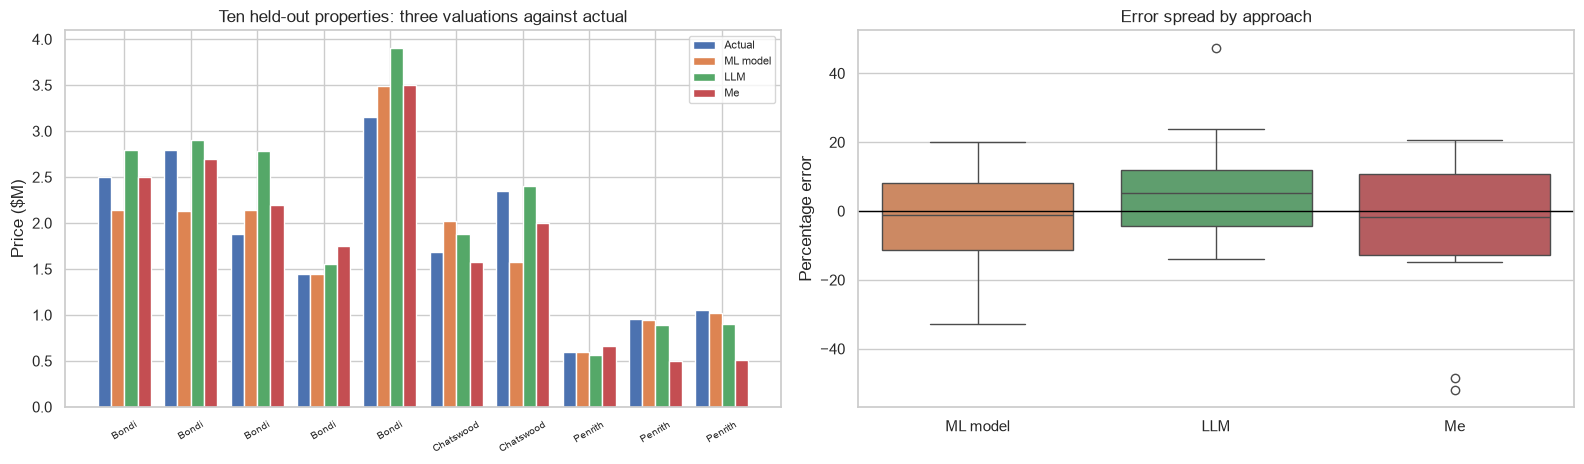


Property by property:

   suburb      type  bed  actual_price  ml_prediction  llm_estimate  my_estimate
    Bondi Apartment    3       2500000      2140000.0       2800000      2500000
    Bondi Apartment    3       2800000      2126000.0       2900000      2700000
    Bondi Apartment    3       1885000      2145000.0       2780000      2200000
    Bondi Apartment    2       1450000      1448000.0       1550000      1750000
    Bondi     House    3       3150000      3487000.0       3900000      3500000
Chatswood Apartment    3       1680000      2019000.0       1880000      1580000
Chatswood     House    2       2350000      1578000.0       2400000      2000000
  Penrith Apartment    2        600000       601000.0        560000       660000
  Penrith     House    3        960000       942000.0        895000       495000
  Penrith     House    3       1050000      1026000.0        905000       505000


In [19]:
FILLED = Path("data/part5_estimates_filled.csv")

if FILLED.exists():
    filled = pd.read_csv(FILLED)
    comparison["my_estimate"] = filled["my_estimate"].values
    comparison["llm_estimate"] = filled["llm_estimate"].values

    for col in ["ml_prediction", "my_estimate", "llm_estimate"]:
        comparison[f"{col}_err"] = comparison[col] - comparison["actual_price"]
        comparison[f"{col}_pct"] = comparison[f"{col}_err"] / comparison["actual_price"] * 100

    err_cols = ["ml_prediction_err", "llm_estimate_err", "my_estimate_err"]
    winner = comparison[err_cols].abs().idxmin(axis=1)
    closest = [int((winner == col).sum()) for col in err_cols]

    scoreboard = pd.DataFrame({
        "approach": ["Machine learning model", "Large language model", "My own estimate"],
        "MAE ($)": [comparison[f"{c}_err"].abs().mean()
                    for c in ["ml_prediction", "llm_estimate", "my_estimate"]],
        "MAPE (%)": [comparison[f"{c}_pct"].abs().mean()
                     for c in ["ml_prediction", "llm_estimate", "my_estimate"]],
        "median bias ($)": [comparison[f"{c}_err"].median()
                            for c in ["ml_prediction", "llm_estimate", "my_estimate"]],
        "closest on N of 10": closest}).set_index("approach")

    print("Three approaches against the true sale price:\n")
    print(scoreboard.round({"MAE ($)": 0, "MAPE (%)": 2, "median bias ($)": 0}).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
    pos = np.arange(10); w = 0.2
    axes[0].bar(pos - 1.5 * w, comparison["actual_price"] / 1e6, w, label="Actual", color="#4c72b0")
    axes[0].bar(pos - 0.5 * w, comparison["ml_prediction"] / 1e6, w, label="ML model", color="#dd8452")
    axes[0].bar(pos + 0.5 * w, comparison["llm_estimate"] / 1e6, w, label="LLM", color="#55a868")
    axes[0].bar(pos + 1.5 * w, comparison["my_estimate"] / 1e6, w, label="Me", color="#c44e52")
    axes[0].set_xticks(pos)
    axes[0].set_xticklabels(comparison["suburb"], rotation=30, fontsize=7)
    axes[0].set(ylabel="Price ($M)", title="Ten held-out properties: three valuations against actual")
    axes[0].legend(fontsize=8)

    err = comparison[["ml_prediction_pct", "llm_estimate_pct", "my_estimate_pct"]]
    err.columns = ["ML model", "LLM", "Me"]
    sns.boxplot(data=err, ax=axes[1], palette=["#dd8452", "#55a868", "#c44e52"])
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set(ylabel="Percentage error", title="Error spread by approach")
    plt.tight_layout(); plt.show()

    print("\nProperty by property:\n")
    print(comparison[["suburb", "type", "bed", "actual_price", "ml_prediction",
                      "llm_estimate", "my_estimate"]].to_string(index=False))
else:
    print("data/part5_estimates_filled.csv not found.")
    print("Fill in the blank file with your own and the LLM's estimates, save it under that name,")
    print("then re-run this cell to produce the comparison.")

**Which approach valued these properties best, and whether human judgement still adds anything.**
**The headline result is that the three approaches cannot be ranked without first deciding what
"best" means.**

| Approach | MAE | MAPE | Median bias | Closest on |
|---|---|---|---|---|
| Machine learning model | $278,700 | **12.05%** | −$10,000 | **6 of 10** |
| DeepSeek-V4.1-Flash | $264,500 | 13.50% | +$100,000 | 2 of 10 |
| My own estimate | **$258,500** | 18.33% | −$50,000 | 2 of 10 |

**Every metric crowns a different winner.** I have the lowest mean absolute error, the model has the
lowest percentage error and is closest on six of the ten properties, and the language model sits
between the two. This is not a contradiction — it is the direct consequence of MAE being measured in
dollars and MAPE in proportions. My largest mistakes were on **cheap** properties, where being wrong
by half costs only a few hundred thousand dollars; the model's largest were on **expensive** ones,
where a smaller proportional error costs more in absolute terms. Choosing MAE alone would have let me
declare myself the best valuer on this sample, which the property-by-property numbers show plainly
that I was not.

**Where the machine learning model succeeded.** Its accuracy on Penrith was remarkable — errors of
**+0.2%, −1.9% and −2.3%** on the three Penrith properties, including one predicted to within
**$1,000** of its true sale price, and a Bondi apartment predicted to within **$2,000**. These are
exactly the conditions it was built for: numerous, standardised properties in the suburb where it had
the most and the least biased data.

**Where it failed, and it failed predictably.** Its two worst predictions of the ten were both
**Chatswood** properties — a house under-predicted by **32.9%** and an apartment over-predicted by
**20.2%**. This is the same weakness identified in Parts 1, 3 and 4 appearing yet again in a fresh
sample: Chatswood withheld 48% of its sale prices, so the model learned that suburb from half a
market. The failure is structural, not bad luck, and it is traceable all the way back to a collection
constraint.

**Where the language model succeeded and failed.** It was the strongest performer on the two
Chatswood properties, including a house it valued within **2.1%** — precisely where the trained model
was weakest. It has no dataset to be biased by, and it draws on a general familiarity with Sydney
prices that a model trained on 201 rows simply does not possess. Against that, it carries a clear
**upward bias of +$100,000**, over-valuing seven of ten properties, and produced the single largest
error of any approach: a Bondi apartment estimated at $2,780,000 that sold for $1,885,000, an
overestimate of **47.5%**. It is fluent and plausible without being calibrated, and it cannot tell
you how uncertain it is.

**Where my own judgement succeeded and failed.** I valued one property **exactly** and was within 4%
on another, both Bondi apartments — the sub-market I had looked at most closely while collecting. But
I made the worst errors of anyone on the two Penrith houses, at **−48.4%** and **−51.9%**. The cause
is instructive: I anchored on Penrith's median of $610,000 without adjusting for the fact that the
median is dominated by apartments, while both properties were houses on 562 and 632 sqm of land. I
substituted a suburb-level statistic for property-level reasoning. The model, which had `is_house`
and `land_size_sqm` in front of it, made no such mistake and predicted both within 2.5%.

**Does human judgement still contribute value?** On this evidence, **yes, but not as a substitute for
the model**. My advantage was concentrated where I had direct familiarity, and my failures were
exactly where I fell back on a remembered average. The model is the opposite: uniformly reliable
across its well-sampled territory, and systematically wrong in the places its data is weakest. The
language model is a third thing again — broad, uncalibrated, and confident everywhere.

The honest conclusion is that the three fail in **uncorrelated** ways, which is what makes the human
worth keeping. The model's worst two properties were the ones the language model handled best; my
worst two were the ones the model handled almost perfectly. A human who knows *where the model is
weak* — and Parts 3 and 4 say exactly where that is — adds real value by overriding it in Chatswood
and at the top of the market, and by leaving it alone everywhere else. That is a narrower role than
"human expert beats machine", and it is the one the evidence actually supports.

**What this says about automation.** The model is the best default: it is the most consistently
accurate, it is nearly unbiased, and it is the only one of the three that can state its own
uncertainty. But it earned that position on a sample drawn mostly from territory it knows well. The
right design is not to choose between the three, but to automate the common case and route the known
failure modes — Chatswood, unusual properties, anything above $4M — to a person. That is why the
application reports a range rather than a number, and warns when a prediction crosses into the region
where Part 4 showed it cannot be trusted.

## Part 6. Deployment and reflection

The selected model is refitted on **all** the collected data and saved to disk, so the web application
loads a ready-made pipeline rather than retraining on startup. Because the saved object is the whole
pipeline — imputation, scaling, one-hot encoding and the model together — the application can hand it
raw property details in exactly the form a user types them, and every preprocessing step applied during
training is reapplied identically.

In [20]:
import joblib

final_model = best_model.fit(X, y)
Path("app").mkdir(exist_ok=True)
joblib.dump({"pipeline": final_model,
             "numeric": NUMERIC,
             "categorical": CATEGORICAL,
             "suburbs": SUBURBS,
             "property_types": sorted(df["property_type"].unique().tolist()),
             "trained_on": len(df),
             "model_name": BEST,
             "cv_mape": float(tuned_results.loc[BEST, "MAPE (%)"]),
             "cv_mae": float(tuned_results.loc[BEST, "MAE ($)"]),
             "defaults": {"sale_month_index": float(df["sale_month_index"].max())},
             "date_min": str(df["sale_date"].min().date()),
             "date_max": str(df["sale_date"].max().date())},
            "app/price_model.joblib")

print(f"Saved app/price_model.joblib")
print(f"  model: {BEST}")
print(f"  fitted on all {len(df)} collected properties")
print(f"  predicts log(price); the application exponentiates back to dollars")
print(f"  cross-validated MAPE carried into the app for its uncertainty range: "
      f"{tuned_results.loc[BEST, 'MAPE (%)']:.1f}%")

check = joblib.load("app/price_model.joblib")
demo = X.iloc[[0]]
print(f"\nReload check — predicts ${np.exp(check['pipeline'].predict(demo))[0]:,.0f} "
      f"for the first property (actual ${df['sale_price'].iloc[0]:,.0f})")

Saved app/price_model.joblib
  model: Random forest
  fitted on all 201 collected properties
  predicts log(price); the application exponentiates back to dollars
  cross-validated MAPE carried into the app for its uncertainty range: 18.0%

Reload check — predicts $1,526,182 for the first property (actual $1,581,000)


**How the application was built, how to run it, and a reflection on the whole workflow.**
**How the application was built.** The deployed tool is a **Streamlit** application (`app/app.py`).
Part 6 of this notebook refits the selected random forest on all 201 properties and saves it with
`joblib` as `app/price_model.joblib`. What is saved is the *entire pipeline* — median imputation,
standard scaling, one-hot encoding and the model together — not just the estimator. That matters:
the application can hand it raw property details exactly as a user types them, and every preprocessing
step applied during training is reapplied identically, so there is no risk of the app and the notebook
disagreeing about how a feature is prepared. Alongside the pipeline the file stores the feature lists,
the suburb and property-type options, and the cross-validated error used for the uncertainty range, so
the interface is built from the model rather than hard-coded against it.

The interface has three tabs. **Estimate one property** takes suburb, type, bedrooms, bathrooms, car
spaces, sale method and — depending on the property type — land or internal area, then returns a price
with a ±18% band. **Upload a CSV** values many properties at once and returns a downloadable file.
**About this model** states what the model is, what it was trained on, and where it fails.

**Running it.**

```bash
pip install -r app/requirements.txt
jupyter notebook 8.1D.ipynb     # Run All - writes app/price_model.joblib
streamlit run app/app.py        # opens at http://localhost:8501
```

The notebook must be run first and from the project folder, because the app loads the model file it
writes.

**A deliberate design decision.** The application reports a **range, not a number**, and it warns
explicitly when a prediction exceeds $4M that the model reads low. A decision support tool that
displays "$4,596,359" invites a confidence that a 19% typical error cannot support. Communicating the
uncertainty is the difference between a tool that helps and one that misleads.

---

### Reflection on the workflow

**Data collection was the hardest part, and it determined everything downstream.** Roughly 70% of the
effort went into obtaining 201 rows, and every significant limitation in the final model traces back
to a decision made during collection. The single most consequential finding of the project is not a
model result at all — it is that **Chatswood withholds 49% of its sale prices against Penrith's 4%**,
and that this gap reappears untouched as a fourfold difference in model error (32.9% against 8.1%).
Had I looked only at aggregate accuracy, I would have missed it entirely.

**Preprocessing mattered more than model choice.** The three models finish within $253 of each other
on MAE. By contrast, the single decision to recognise that Domain's `m²` field mixes internal area
with block site area — a $325,000 apartment recorded against 28,725 sqm — was worth far more than any
amount of hyperparameter tuning. Time spent understanding one ambiguous column beat time spent
searching a parameter grid, decisively.

**Two of my three prior expectations held; the interesting one failed.** I predicted suburb and
bedroom count would dominate, and both did. I predicted land size would be third, and it correlated at
**0.008** — because land is recorded only for houses and the same area means different things in
different suburbs. Being specific in advance is what made the failure visible; a vaguer prediction
would have been unfalsifiable.

**What the data said about why I chose these suburbs.** Each suburb was chosen for a stated reason,
and the evidence treats the three very differently.

The **Bondi** thesis — that you buy the postcode more than the dwelling — is **supported**. Location
overwhelms every physical attribute in the fitted model, and the suburb indicator is the single
strongest feature by a wide margin. The corollary is uncomfortable, though: if the postcode does most
of the pricing, a model that knows the postcode and little else will look accurate while telling you
almost nothing about which property to buy *within* it.

The **Chatswood** thesis — best liquidity-to-cost — is **not something this dataset can measure**,
but collecting the data surfaced a friction the thesis did not anticipate. Chatswood withholds 48% of
its sale prices against Penrith's 4%. A buyer who wants to judge value from comparable sales has half
the evidence available to them there, and the model inherits exactly that handicap: it is four times
less accurate in Chatswood than in Penrith. Liquidity and price transparency are not the same thing,
and the cheaper-to-enter market turned out to be the harder one to value.

The **Penrith** thesis — that the land is the asset and the house barely matters — is the one the
data **does not support**, though the test is weak rather than conclusive. Land size correlates with
price at **0.008** and ranks eleventh of twelve features by importance. The honest caveat is that land
is recorded for only 36 properties and the sample is apartment-heavy, so this is a failure to find
evidence rather than evidence of absence; a larger sample with a land-by-suburb interaction would be
the proper test. There is a postscript worth recording: in Part 5 I under-valued both Penrith houses
by roughly half, having anchored on a suburb median dominated by apartments. I held a thesis that
Penrith land was the thing to buy and then, when asked to price two houses on 562 and 632 sqm of it,
priced them as though the land were not there.

**The trade-off between accuracy and deployability.** The random forest was selected, but Ridge regression is about 10% behind on MAE with a validation gap four times smaller, and it can explain any
prediction as a sum of contributions. For a real agency that had to justify valuations to clients, the
interpretable model would very likely be the better product despite being marginally less accurate.
Accuracy is not the only thing a deployed model is judged on.

### Ethical implications

**The model is least accurate where the data is thinnest, and that is not ethically neutral.** It is
four times worse in Chatswood than in Penrith, and it over-predicts Chatswood by 20%. A buyer relying
on it would systematically overpay there, and a seller relying on it in Bondi would price a
high-end home far too low — the top-of-market failures run to 49%. Errors of this kind are not random
noise; they fall on identifiable groups of people in a consistent direction.

**The training data inherits a market's disclosure practices.** Withheld prices are concentrated at
the top of the market and on poor results. A model trained only on disclosed sales therefore learns a
partial version of the market and reproduces that partiality in every prediction, while presenting the
result with the same apparent authority for every property.

**Automated valuation invites feedback loops.** If such a tool were used at scale to set offers, its
predictions would begin to influence the sale prices that later become its training data. Under-pricing
unusual properties would then become self-confirming.

**What I would do with more data, time or resources.** Collect **agent descriptions and photographs**
to capture condition and quality, the dominant missing variable. Extend to several years so that time
trends could be separated from composition. Add geocoding, so that distance to a station, a beach or a
main road becomes measurable instead of assumed. Use the NSW Valuer General's public sales register to
recover the withheld prices and directly measure the bias rather than merely describing it. And gather
enough high-value sales to let the model learn the top of the market instead of averaging it away.

**Overall.** The model explains about 88% of the variance in log price and predicts a typical property
within roughly 19%. That is a usable rough guide and a genuinely useless valuation, and the most
valuable thing this project produced is a clear account of *which* properties it should not be trusted
for and *why*.